## Visualization: Mapping Plotting

This project introduces the Cartopy library, which can be used to create maps and plot geographical datasets.

Install it by next code: pip install cartopy

### Making a simple map

Let's start out by making a simple map of the world. If you run the following code, you should get a nice map of the globe, with good clean coastlines:

In [1]:
# This just lets the output of the following code samples
#  display inline on this page, at an appropriate size.
from pylab import rcParams

%matplotlib inline
rcParams['figure.figsize'] = (8,6)

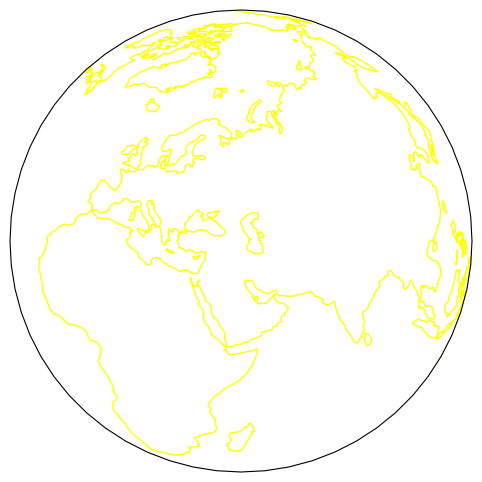

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature

# Create a Cartopy Orthographic projection
ortho = ccrs.Orthographic(central_longitude=47, central_latitude=40)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': ortho})

# Add the manually downloaded Natural Earth coastline data
coastline_feature = NaturalEarthFeature('physical', 'coastline', '110m',
                                        edgecolor='yellow', facecolor='none', linewidth=1)
ax.add_feature(coastline_feature)

plt.show()

### Adding detail

Let’s add some more detail to this map, starting with country borders.  Add the following `add_feature()`:

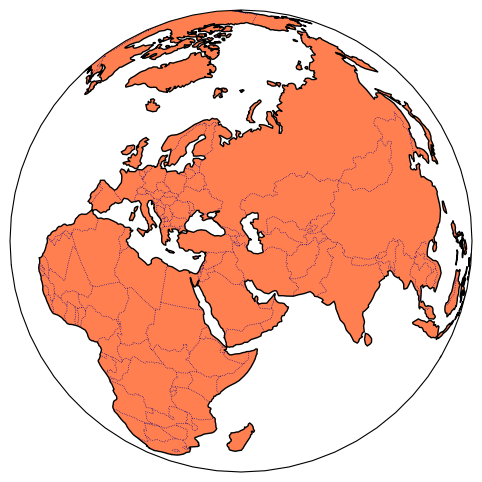

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import COASTLINE, BORDERS, LAND


# Create a Cartopy Orthographic projection
ortho = ccrs.Orthographic(central_longitude=47, central_latitude=40)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': ortho})

# Add Cartopy features
ax.add_feature(COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(BORDERS, linestyle=':', linewidth=0.5, edgecolor='darkblue')
ax.add_feature(LAND, facecolor='coral')

plt.show()

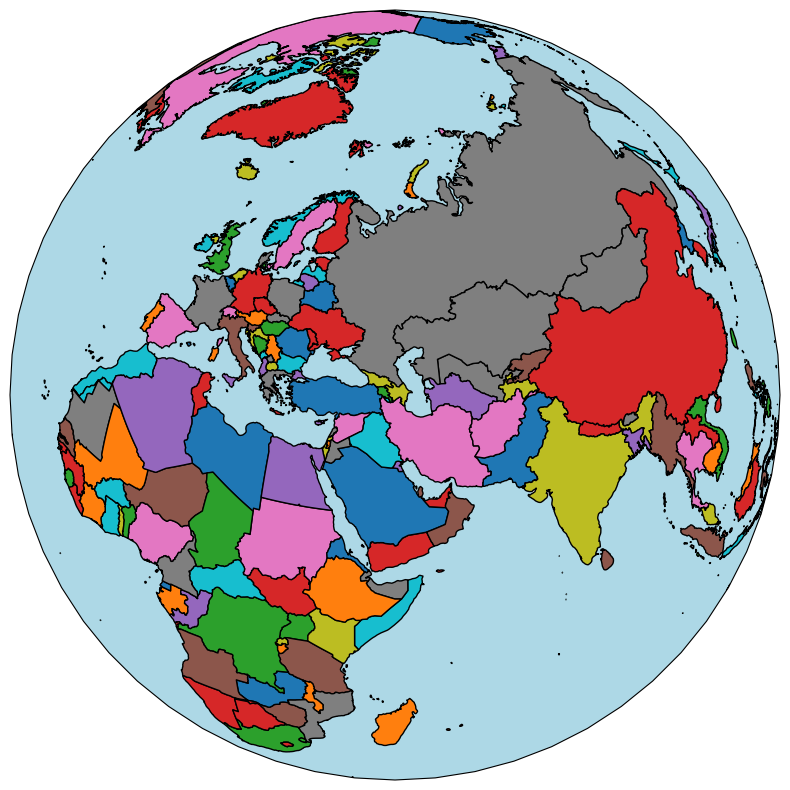

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
import numpy as np

# Create a Cartopy Orthographic projection centered on Europe
ortho = ccrs.Orthographic(central_longitude=47, central_latitude=40)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': ortho}, figsize=(10, 10))

# Add Natural Earth countries feature
countries = NaturalEarthFeature(
    category='cultural',
    name='admin_0_countries',
    scale='50m',
    edgecolor='black'
)

# Define a color map for each country
np.random.seed(0)  # for reproducibility
num_countries = len(list(countries.geometries()))
colors = [plt.cm.tab10(i) for i in np.random.choice(range(10), size=num_countries)]

# Add European countries with different colors
ax.add_feature(countries, facecolor=colors, linewidth=1)
ax.add_feature(cfeature.OCEAN, color='lightblue')

plt.show()

A global earthquake dataset
===
The US government maintains a set of [live feeds](http://earthquake.usgs.gov/earthquakes/feed/v1.0/) of earthquake-related data from recent seismic events. You can choose to examine data from the last hour, through the last thirty days. You can choose to examine data from events that have a variety of magnitudes. For this project, we'll use a dataset that contains all seismic events over the last seven days, which have a magnitude of 1.0 or greater.

You can also choose from a variety of formats. In this first example, we'll look at how to parse a file in the csv format (comma-separated value). There are more convenient formats to work with such as json, but not all data sets are neatly organized. We'll start out parsing a csv file, and then perhaps take a look at how to work with the json format.

To follow this project on your own system, go to the [USGS source](http://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php) for csv files of earthquake data and download the file "M1.0+ Earthquakes" under the "Past 7 Days" header. If you like, here is a [direct link](http://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/1.0_week.csv) to that file. This data is updated every 5 minutes, so your data won't match what you see here exactly. The format should match, but the data itself won't match.

Parsing the data
---
If we examine the first few lines of the text file of the dataset, we can identify the information that's most relevant to us:

    time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
    2015-04-25T14:25:06.520Z,40.6044998,-121.8546677,17.65,1.92,md,7,172,0.0806,0.02,nc,nc72435025,2015-04-25T14:31:51.640Z,"12km NNE of Shingletown, California",earthquake
    2015-04-25T14:21:16.420Z,37.6588326,-122.5056686,7.39,2.02,md,21,99,0.07232,0.04,nc,nc72435020,2015-04-25T14:26:05.693Z,"3km SSW of Broadmoor, California",earthquake
    2015-04-25T14:14:40.000Z,62.6036,-147.6845,43.1,1.7,ml,,,,0.67,ak,ak11565061,2015-04-25T14:40:18.782Z,"108km NNE of Sutton-Alpine, Alaska",earthquake
    2015-04-25T14:10:02.830Z,27.5843,85.6622,10,4.6,mb,,86,5.898,0.87,us,us20002965,2015-04-25T14:38:25.174Z,"14km E of Panaoti, Nepal",earthquake
    2015-04-25T13:55:47.040Z,33.0888333,-116.0531667,5.354,1.09,ml,23,38,0.1954,0.26,ci,ci37151511,2015-04-25T13:59:57.204Z,"10km SE of Ocotillo Wells, California",earthquake

For now, we're only interested in the latitude and longitude of each earthquake.  If we look at the first line, it looks like we're interested in the second and third columns of each line.  In the directory where you save your program files, make a directory called “datasets”.  Save the text file as “earthquake_data.csv” in this new directory.

Using Python's csv module to parse the data
---
We'll process the data using Python's [csv module](http://docs.python.org/3.3/library/csv.html) module, which simplifies the process of working with csv files.

The following code produces two lists, containing the latitudes and longitudes of each earthquake in the file:

In [5]:
import csv

# Open the earthquake data file.
filename = 'datasets/earthquake_data.csv'

# Create empty lists for the latitudes and longitudes.
lats, lons = [], []

# Read through the entire file, skip the first line,
#  and pull out just the lats and lons.
with open(filename) as f:
    # Create a csv reader object.
    reader = csv.reader(f)
    
    # Ignore the header row.
    next(reader)
    
    # Store the latitudes and longitudes in the appropriate lists.
    for row in reader:
        lats.append(float(row[1]))
        lons.append(float(row[2]))
        
# Display the first 5 lats and lons.
print('lats', lats[0:5])
print('lons', lons[0:5])

lats [40.6044998, 37.6588326, 62.6036, 27.5843, 33.0888333]
lons [-121.8546677, -122.5056686, -147.6845, 85.6622, -116.0531667]


We create empty lists to contain the latitudes and longitudes. Then we use the `with` statement to ensure that the file closes properly once it has been read, even if there are errors in processing the file.

With the data file open, we initialize a csv reader object. The `next()` function skips over the header row. Then we loop through each row in the data file, and pull out the information we want.

[top](#)

Plotting earthquakes
---
Using what we learned about plotting a set of points, we can now make a simple plot of these points:

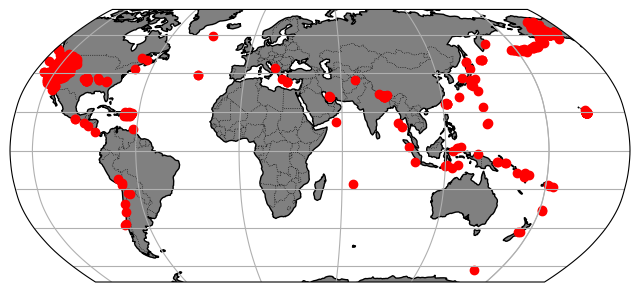

In [6]:
import csv

# Open the earthquake data file.
filename = 'datasets/earthquake_data.csv'

# Create empty lists for the latitudes and longitudes.
lats, lons = [], []

# Read through the entire file, skip the first line,
#  and pull out just the lats and lons.
with open(filename) as f:
    # Create a csv reader object.
    reader = csv.reader(f)
    
    # Ignore the header row.
    next(reader)
    
    # Store the latitudes and longitudes in the appropriate lists.
    for row in reader:
        lats.append(float(row[1]))
        lons.append(float(row[2]))
 
# --- Build Map ---
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Create a Cartopy Robinson projection
robinson = ccrs.Robinson(central_longitude=47)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': robinson})

# Add Cartopy features
ax.add_feature(COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.gridlines()

# Plot points on the map
ax.plot(lons, lats, 'ro', markersize=6, transform=ccrs.PlateCarree())

plt.show()

Adding color
---
There's one more change we can make, to generate a more meaningful visualization.  Let’s use some different colors to represent the magnitudes as well.  Let's make small earthquakes green, moderate earthquakes yellow, and significant earthquakes red.  The following version includes a function that identifies the appropriate color for each earthquake:

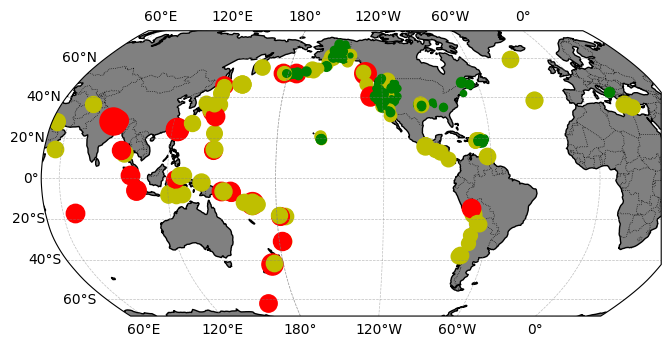

In [7]:
###highlight=[31,32,33,34,35,36,37,38,39,54,55]
import csv

# Open the earthquake data file.
filename = 'datasets/earthquake_data.csv'

# Create empty lists for the data we are interested in.
lats, lons = [], []
magnitudes = []

# Read through the entire file, skip the first line,
#  and pull out just the lats and lons.
with open(filename) as f:
    # Create a csv reader object.
    reader = csv.reader(f)
    
    # Ignore the header row.
    next(reader)
    
    # Store the latitudes and longitudes in the appropriate lists.
    for row in reader:
        lats.append(float(row[1]))
        lons.append(float(row[2]))
        magnitudes.append(float(row[4]))
        
# --- Build Map ---
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def get_marker_color(magnitude):
    # Returns green for small earthquakes, yellow for moderate
    #  earthquakes, and red for significant earthquakes.
    if magnitude < 3.0:
        return ('go')
    elif magnitude < 5.0:
        return ('yo')
    else:
        return ('ro')

# Create a Cartopy Robinson projection
eq_map = ccrs.Robinson(central_longitude=-130)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': eq_map})

# Add Cartopy features
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='gray')

# Draw parallels and meridians
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

min_marker_size = 2.5
for lon, lat, mag in zip(lons, lats, magnitudes):
    x, y = eq_map.transform_point(lon, lat, ccrs.PlateCarree())
    msize = mag * min_marker_size
    marker_string = get_marker_color(mag)
    ax.plot(x, y, marker_string, markersize=msize)

plt.show()

Now we can easily see where the most significant earthquakes are happening.

[top](#)

Adding a title
---
Before we finish, let’s add a title to our map.  Our title needs to include the date range for these earthquakes, which requires us to pull in a little more data when we parse the raw text. To make the title, we'll use the dates of the first and last earthquakes.  Since the file includes the most recent earthquakes first, we need to use the last items as the starting date:

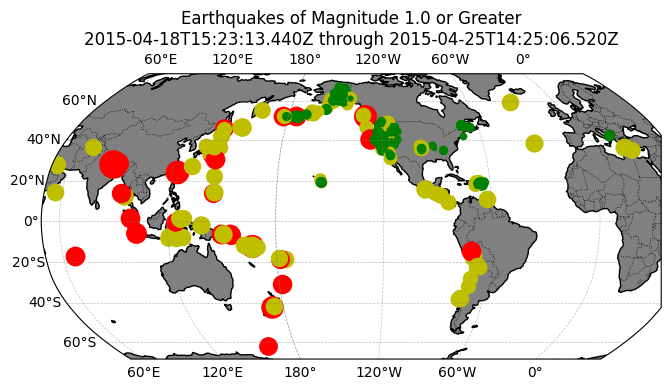

In [8]:
###highlight=[10,26,59,60,61]
import csv

# Open the earthquake data file.
filename = 'datasets/earthquake_data.csv'

# Create empty lists for the data we are interested in.
lats, lons = [], []
magnitudes = []
timestrings = []

# Read through the entire file, skip the first line,
#  and pull out just the lats and lons.
with open(filename) as f:
    # Create a csv reader object.
    reader = csv.reader(f)
    
    # Ignore the header row.
    next(reader)
    
    # Store the latitudes and longitudes in the appropriate lists.
    for row in reader:
        lats.append(float(row[1]))
        lons.append(float(row[2]))
        magnitudes.append(float(row[4]))
        timestrings.append(row[0])
        
# --- Build Map ---
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def get_marker_color(magnitude):
    if magnitude < 3.0:
        return ('go')
    elif magnitude < 5.0:
        return ('yo')
    else:
        return ('ro')

# Create a Cartopy Robinson projection
eq_map = ccrs.Robinson(central_longitude=-130)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': eq_map})

# Add Cartopy features
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='gray')

# Draw parallels and meridians
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

min_marker_size = 2.5
for lon, lat, mag in zip(lons, lats, magnitudes):
    x, y = eq_map.transform_point(lon, lat, ccrs.PlateCarree())
    msize = mag * min_marker_size
    marker_string = get_marker_color(mag)
    ax.plot(x, y, marker_string, markersize=msize)

title_string = "Earthquakes of Magnitude 1.0 or Greater\n"
title_string += "%s through %s" % (timestrings[-1], timestrings[0])
ax.set_title(title_string)

plt.show()

This is good, but the time zone format makes the title a little harder to read. Let's just use the dates, and ignore the times in our title. We can do this by keeping the first 10 characters of each `timestring`, using a slice: `timestring[:10]`. Since this is the final iteration for this project, let's also make the plot size larger as well:

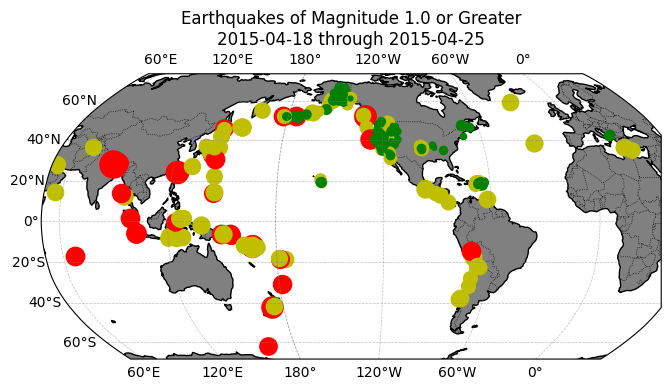

In [9]:
###highlight=[10,26,59,60,61]
import csv

# Open the earthquake data file.
filename = 'datasets/earthquake_data.csv'

# Create empty lists for the data we are interested in.
lats, lons = [], []
magnitudes = []
timestrings = []

# Read through the entire file, skip the first line,
#  and pull out just the lats and lons.
with open(filename) as f:
    # Create a csv reader object.
    reader = csv.reader(f)
    
    # Ignore the header row.
    next(reader)
    
    # Store the latitudes and longitudes in the appropriate lists.
    for row in reader:
        lats.append(float(row[1]))
        lons.append(float(row[2]))
        magnitudes.append(float(row[4]))
        timestrings.append(row[0])
        
# --- Build Map ---
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def get_marker_color(magnitude):
    if magnitude < 3.0:
        return ('go')
    elif magnitude < 5.0:
        return ('yo')
    else:
        return ('ro')

# Create a Cartopy Robinson projection
eq_map = ccrs.Robinson(central_longitude=-130)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': eq_map})

# Add Cartopy features
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='gray')

# Draw parallels and meridians
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

min_marker_size = 2.5
for lon, lat, mag in zip(lons, lats, magnitudes):
    x, y = eq_map.transform_point(lon, lat, ccrs.PlateCarree())
    msize = mag * min_marker_size
    marker_string = get_marker_color(mag)
    ax.plot(x, y, marker_string, markersize=msize)

title_string = "Earthquakes of Magnitude 1.0 or Greater\n"
title_string += "%s through %s" % (timestrings[-1][:10], timestrings[0][:10])
ax.set_title(title_string)

plt.show()

To get a sense of how flexible the basemap library is, check out how quickly you can change the look and feel of this map.  Comment out the line that colors the continents, and replace it with a call to bluemarble. You might want to adjust `min_marker_size` as well, if you make this map on your own system:

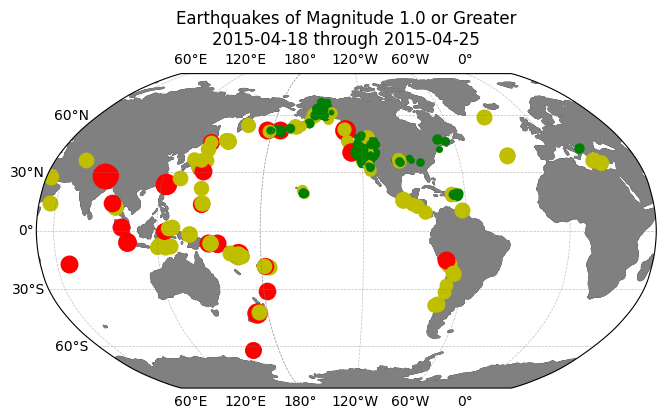

In [10]:
###highlight=[47,48,53]
import csv

# Open the earthquake data file.
filename = 'datasets/earthquake_data.csv'

# Create empty lists for the data we are interested in.
lats, lons = [], []
magnitudes = []
timestrings = []

# Read through the entire file, skip the first line,
#  and pull out just the lats and lons.
with open(filename) as f:
    # Create a csv reader object.
    reader = csv.reader(f)
    
    # Ignore the header row.
    next(reader)
    
    # Store the latitudes and longitudes in the appropriate lists.
    for row in reader:
        lats.append(float(row[1]))
        lons.append(float(row[2]))
        magnitudes.append(float(row[4]))
        timestrings.append(row[0])
        
# --- Build Map ---
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def get_marker_color(magnitude):
    if magnitude < 3.0:
        return ('go')
    elif magnitude < 5.0:
        return ('yo')
    else:
        return ('ro')

# Create a Cartopy Robinson projection
eq_map = ccrs.Robinson(central_longitude=-130)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(subplot_kw={'projection': eq_map})

# Add Cartopy features
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            edgecolor='face', facecolor='gray'))

ax.set_global()  # Set the extent to global
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

min_marker_size = 2.25
for lon, lat, mag in zip(lons, lats, magnitudes):
    x, y = eq_map.transform_point(lon, lat, ccrs.PlateCarree())
    msize = mag * min_marker_size
    marker_string = get_marker_color(mag)
    ax.plot(x, y, marker_string, markersize=msize)

title_string = "Earthquakes of Magnitude 1.0 or Greater\n"
title_string += "%s through %s" % (timestrings[-1][:10], timestrings[0][:10])
ax.set_title(title_string)

plt.show()

We could continue to refine this map.  For example, we could read the data from the url instead of from a downloaded text file.  That way the map would always be current.  We could determine each dot’s color on a continuous scale of greens, yellows, and reds.  Now that you have a better sense of how to work with basemap, I hope you enjoy playing with these further refinements as you map the datasets you're most interested in.